In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from scipy.stats import rankdata
from scipy.stats import mannwhitneyu
from scipy.stats import chi2_contingency
from decimal import Decimal
import itertools
import csv
import seaborn as sns
import requests
import re
import ast

In [1]:
def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def spearman(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = spearmanr(data1, data2)
    return correlation, p_value

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('scatter.png')
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    # plt.savefig('loglog.png')
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def pearson(dict1, dict2):
    valid_keys, data1, data2 = todata(dict1, dict2)
    correlation, p_value = pearsonr(data1, data2)
    formatted_p_value = '{:e}'.format(p_value)
    return correlation, formatted_p_value

def get_reactions_for_compound(compound_id):
    response = requests.get(f'https://rest.kegg.jp/link/reaction/{compound_id}')
    lines = response.text.split('\n')
    
    reactions = []
    for line in lines:
        try:
            reactions.append(line.split('\t')[1][3:])
        except:
            pass
    return reactions

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        lines = csv_file.readlines()
        for line in lines:
            # Create a dictionary
            result_dict[line.split(',')[0]] = line.split(',')[1].strip()
    return result_dict

def rxnWith(xgroup, rn2rules):
    rxnWithX = []
    for reaction, rules in rn2rules.items():
        for rule in rules:
            if xgroup in rule:
                rxnWithX.append(reaction)
                break
    return rxnWithX

## vanilla

In [4]:
# vanilla = csv2dict2('../vanilla_ne.csv')
# vanilla.pop('\ufeffCompound ID')

vanilla = csv2dict2('../data/assets/vanilla_withAA.csv')

In [5]:
len(vanilla)

4315

## fold-gated (random)

In [6]:
df_random = pd.read_csv('../cpds_cumiter_random-order_1000runs.csv', index_col=0)

In [7]:
df_random.head()  # fold-gated

,37296,12225,7470,5925,43989,27811,65153,30847,16362,41985,...,53395,51260,8783,3661,11936,9964,56140,33208,53388,58845
Z00020,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C14819,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00048,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00023,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00041,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [8]:
len(df_random.index)

4318

In [9]:
df_random = df_random.drop('C00034')  # Mn
df_random = df_random.drop('C00050')  # metal
df_random = df_random.drop('Z00020')  # Generic FeS cluster

In [10]:
len(df_random.columns)

1000

In [11]:
runs_random = df_random.columns.tolist()

In [12]:
len(runs_random)

1000

## fold-gated (BATM: BestAtTheMoment)

In [13]:
batm1 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-36_no_look_ahead_rules_ignore_versions_3141.pkl.gz')
# batm2 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-32-54_no_look_ahead_rules_ignore_versions_3142.pkl.gz')
# batm3 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-33-00_no_look_ahead_rules_ignore_versions_3143.pkl.gz')
# batm4 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-33-09_no_look_ahead_rules_ignore_versions_3144.pkl.gz')
# batm5 = pd.read_pickle('../no_look_ahead_rules_ignore_versions.pkl/2023-09-12_17-33-19_no_look_ahead_rules_ignore_versions_3145.pkl.gz')

In [14]:
batm1.cpds_cumiter

{'Z00002': 0,
 'C14819': 0,
 'Z00033': 0,
 'C06232': 0,
 'C00048': 0,
 'Z00029': 0,
 'C00205': 0,
 'C01330': 0,
 'C00034': 0,
 'C00183': 0,
 'C00036': 0,
 'C17023': 0,
 'Z00060': 0,
 'C00188': 0,
 'C01528': 0,
 'C20679': 0,
 'C00069': 0,
 'C19609': 0,
 'C00033': 0,
 'Z00069': 0,
 'C00123': 0,
 'C14818': 0,
 'Z00020': 0,
 'C00383': 0,
 'Z00034': 0,
 'C00149': 0,
 'C00001': 0,
 'C00011': 0,
 'C00288': 0,
 'C00161': 0,
 'C00071': 0,
 'Z00062': 0,
 'Z00055': 0,
 'C00175': 0,
 'Z00064': 0,
 'C00023': 0,
 'C00148': 0,
 'C01732': 0,
 'Z00030': 0,
 'C01127': 0,
 'C00160': 0,
 'C00150': 0,
 'C00038': 0,
 'C00028': 0,
 'C00058': 0,
 'Z00054': 0,
 'C00030': 0,
 'C00050': 0,
 'C00022': 0,
 'C00407': 0,
 'C00238': 0,
 'C00209': 0,
 'Z00063': 0,
 'C00049': 0,
 'C00042': 0,
 'C00065': 0,
 'C19806': 0,
 'Z00053': 0,
 'C01335': 0,
 'Z00001': 0,
 'Z00067': 0,
 'C00009': 0,
 'Z00006': 0,
 'C00014': 0,
 'Z00070': 0,
 'C00037': 0,
 'C00012': 0,
 'C00025': 0,
 'Z00015': 0,
 'C00282': 0,
 'C00417': 0,
 'C000

In [15]:
max(batm1.cpds_cumiter.values())

985

In [16]:
max(vanilla.values())

'9'

In [17]:
max(df_random['37296'])

568

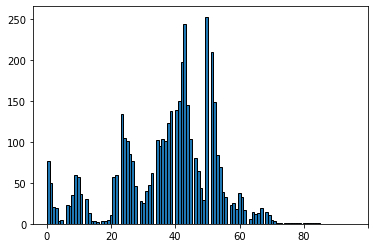

In [18]:
plt.hist(vanilla.values(), bins=100, edgecolor='k')
plt.xticks([0, 20, 40, 60, 80, 100])
plt.show()

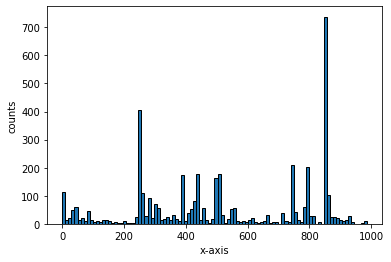

In [19]:
histogram(batm1.cpds_cumiter, bins=100)

## 1000 optimal runs

In [20]:
df_optimal = pd.read_csv('../cpds_cumiter_optimal_1000runs.csv', index_col=0)

In [21]:
df_optimal.head()

,36964,27003,56216,10647,32519,27148,7365,30109,1837,44298,...,8169,34876,45952,57192,16982,28814,34433,30319,58220,224
C00150,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00025,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00049,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
C00058,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
df_optimal = df_optimal.drop('C00034')  # Mn
df_optimal = df_optimal.drop('C00050')  # metal
df_optimal = df_optimal.drop('Z00020')  # AMP?

# Spearman correlations

In [ ]:
corrs_random = []
for run in runs_random:
    corr, p = spearman(vanilla, dict(df_random[run]))
    corrs_random.append(corr)

In [ ]:
# this takes a while
runs_optimal = df_optimal.columns.tolist()

corrs_optimal = []
for run in runs_optimal:
    corr, p = spearman(vanilla, dict(df_optimal[run]))
    corrs_optimal.append(corr)

In [ ]:
np.mean(corrs_random), np.std(corrs_random)

In [ ]:
np.mean(corrs_optimal), np.std(corrs_optimal)

In [ ]:
from scipy.stats import ttest_ind

statistic, p_value = ttest_ind(corrs_random, corrs_optimal)
print(statistic, p_value)

In [ ]:
# plot them together
plt.figure(figsize=(2.2, 4))
plt.hist(corrs_random, bins=20, edgecolor='none', color='gray')
plt.hist(corrs_optimal, bins=5, edgecolor='none', color='blue')
plt.xlabel("Spearman's rank corr. coeff.")
plt.ylabel('runs')
labels = ['random', 'optimal']
plt.legend(labels, loc='upper left')
plt.xlim([0, 1])

# annotate statistical values
plt.text(1.3, 44, f"random:", fontsize=10, verticalalignment='center')
plt.text(1.4, 24, f"mean={np.mean(corrs_random)}", fontsize=10, verticalalignment='center')
plt.text(1.4, 4, f"std={np.std(corrs_random)}", fontsize=10, verticalalignment='center')

plt.text(1.3, 114, f"optimal:", fontsize=10, verticalalignment='center')
plt.text(1.4, 94, f"mean={np.mean(corrs_optimal)}", fontsize=10, verticalalignment='center')
plt.text(1.4, 74, f"std={np.std(corrs_optimal)}", fontsize=10, verticalalignment='center')

plt.text(1.3, 204, f"t-test:", fontsize=10, verticalalignment='center')
plt.text(1.4, 184, f"statistic={statistic}", fontsize=10, verticalalignment='center')
plt.text(1.4, 164, f"p-value={p_value}", fontsize=10, verticalalignment='center')

# plt.savefig('spearman_vanilla_vs_fold-gated.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# mean & std

In [32]:
row_means = df_random.mean(axis=1)
row_stds = df_random.std(axis=1)

In [33]:
row_means

C14819      0.000
C00048      0.000
C00023      0.000
C00041      0.000
C00036      0.000
           ...   
C19156    522.162
C19155    521.162
C01080    531.627
C00876    530.627
Z00011    520.162
Length: 4315, dtype: float64

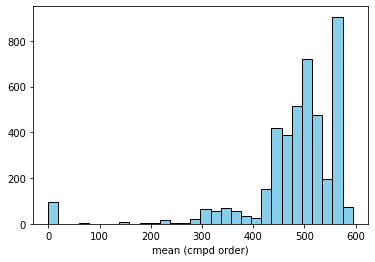

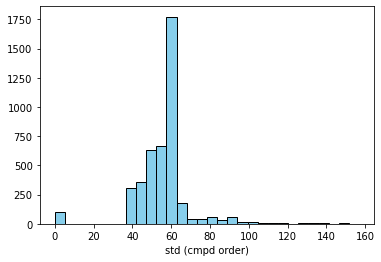

In [34]:
plt.hist(row_means, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('mean (cmpd order)')
plt.show()

plt.hist(row_stds, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('std (cmpd order)')
plt.show()

In [35]:
row_means_opt = df_optimal.mean(axis=1)
row_stds_opt = df_optimal.std(axis=1)

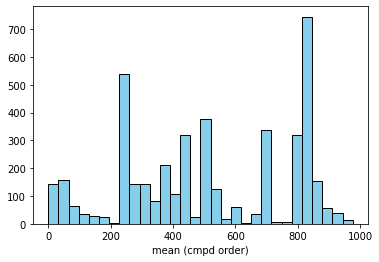

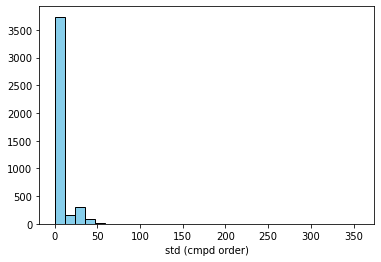

In [36]:
plt.hist(row_means_opt, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('mean (cmpd order)')
plt.show()

plt.hist(row_stds_opt, bins=30, color='skyblue', edgecolor='black')
plt.xlabel('std (cmpd order)')
plt.show()

# fold order vs. cummulative cmpd count --- random vs. optimal

In [5]:
# need folditer, not cumiter
df_random = pd.read_csv('cpds_folditer_random_order_1000runs.csv', index_col=0)
df_optimal = pd.read_csv('cpds_folditer_optimal_1000runs.csv', index_col=0)

In [6]:
for run in df_random.columns[0:9]:
    print(run)

37296
6390
6006
55381
8066
53474
38437
60846
13727


In [39]:
df_random['37296']

Z00020      0
C14819      0
C00048      0
C00023      0
C00041      0
         ... 
C19156    398
C19155    398
C01080    398
C00876    398
Z00011    398
Name: 37296, Length: 4318, dtype: int64

In [10]:
# fo vs. [compounds]

fo2cmpds_random_list = []
for run in df_random.columns:
    fo2cmpds_random = {}
    for c, order in df_random[run].items():
        if order not in fo2cmpds_random.keys():
            fo2cmpds_random[order] = [c]
        else:
            fo2cmpds_random[order].append(c)
    fo2cmpds_random_list.append(fo2cmpds_random)

fo2cmpds_list = []
for run in df_optimal.columns:
    fo2cmpds = {}
    for c, order in df_optimal[run].items():
        if order not in fo2cmpds.keys():
            fo2cmpds[order] = [c]
        else:
            fo2cmpds[order].append(c)
    fo2cmpds_list.append(fo2cmpds)

In [11]:
# fo vs. #compounds

fo2cmpdNum_random_list = []
for run in fo2cmpds_random_list:
    fo2cmpdNum_random = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum_random[i] = cumm 
    fo2cmpdNum_random_list.append(fo2cmpdNum_random)

fo2cmpdNum_list = []
for run in fo2cmpds_list:                   
    fo2cmpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum[i] = cumm
    fo2cmpdNum_list.append(fo2cmpdNum)

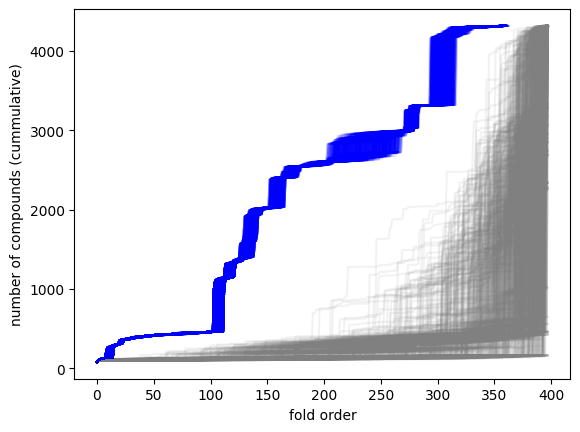

In [15]:
for run in fo2cmpdNum_random_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cmpdNum_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cmpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

In [ ]:
# annotate with key cpds

cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')
cpd_df = pd.read_csv('../cpds_folditer_optimal_1000runs.csv', index_col=0)
cpd2fo_meanNONE = {}
for index in cpd_df.index:
    cpd2fo_meanNONE[index] = np.mean(cpd_df.loc[index])

In [ ]:
cpds = ['C00007','C00024','C00129', 'Z00035', 'C00002', 'C00004', 'C00019', 'C00010', 'C00016', 'Z00047', 'C00353', 'C00032', 'C00059', 'C00082', 'C00078']
for c in cpds:
    print(c, cpd2name[c], cpd2fo_meanNONE[c])

In [ ]:
for run in fo2cmpdNum_random_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=1)
for run in fo2cmpdNum_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=1)
plt.xlabel('Fold order')
plt.ylabel('Network size')

# annotate key cpds
for c in cpds:
    x = cpd2fo_meanNONE[c]
    y = fo2cmpdNum_list[0][round(x)-5]  # just use one run
    plt.text(x, y, cpd2name[c], ha='center', va='bottom', color='red', zorder=3)
    plt.scatter(x, y-5, color='red')   


# plt.savefig('fold_order_vs_cumm_cpds_annotated_random_vs_optimal.svg', dpi=300, bbox_inches = 'tight')
plt.show()

# shuffle

In [33]:
df_preATP = pd.read_csv('peroxide_cumiter_fix/peroxide_cumiter_fix_cpds_folditer_preATP.csv', index_col=0)
df_shuffle = pd.read_csv('shuffle_1_cpds_folditer_preATP.csv', index_col=0)
df_shuffle2 = pd.read_csv('shuffle_2_cpds_folditer_preATP.csv', index_col=0)

In [35]:
# fo vs. [compounds]

fo2cmpds_list = []
for run in df_preATP.columns:
    fo2cmpds = {}
    for c, order in df_preATP[run].items():
        if order not in fo2cmpds.keys():
            fo2cmpds[order] = [c]
        else:
            fo2cmpds[order].append(c)
    fo2cmpds_list.append(fo2cmpds)

fo2cmpds_shuffle_list = []
for run in df_shuffle.columns:
    fo2cmpds = {}
    for c, order in df_shuffle[run].items():
        if order not in fo2cmpds.keys():
            fo2cmpds[order] = [c]
        else:
            fo2cmpds[order].append(c)
    fo2cmpds_shuffle_list.append(fo2cmpds)

fo2cmpds_shuffle2_list = []
for run in df_shuffle2.columns:
    fo2cmpds = {}
    for c, order in df_shuffle2[run].items():
        if order not in fo2cmpds.keys():
            fo2cmpds[order] = [c]
        else:
            fo2cmpds[order].append(c)
    fo2cmpds_shuffle2_list.append(fo2cmpds)

In [36]:
fo2cmpdNum_list = []
for run in fo2cmpds_list:                   
    fo2cmpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum[i] = cumm
    fo2cmpdNum_list.append(fo2cmpdNum)

fo2cmpdNum_shuffle_list = []
for run in fo2cmpds_shuffle_list:                   
    fo2cmpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum[i] = cumm
    fo2cmpdNum_shuffle_list.append(fo2cmpdNum)

fo2cmpdNum_shuffle2_list = []
for run in fo2cmpds_shuffle2_list:                   
    fo2cmpdNum = {}
    cumm = 0
    for i in range(0, max(run.keys())): 
        if i in run.keys():
            cumm += len(run[i])
        fo2cmpdNum[i] = cumm
    fo2cmpdNum_shuffle2_list.append(fo2cmpdNum)

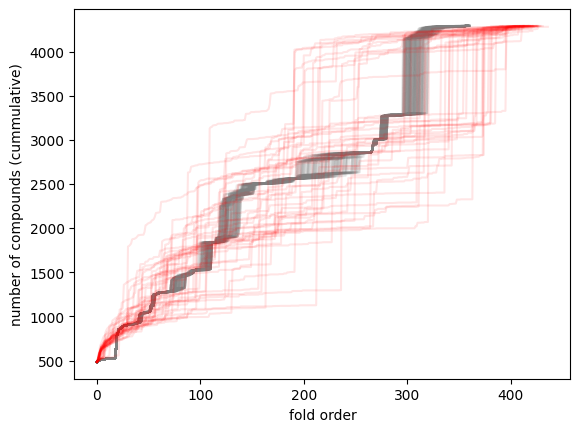

In [37]:
for run in fo2cmpdNum_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cmpdNum_shuffle_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cmpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

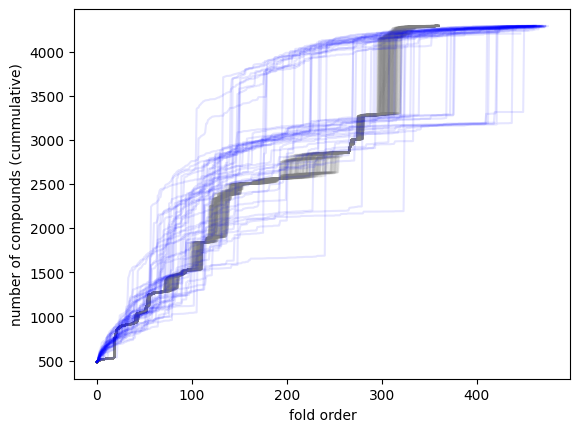

In [39]:
for run in fo2cmpdNum_list:
    plt.plot(run.keys(), run.values(), color='gray', alpha = 0.1,zorder=2)
for run in fo2cmpdNum_shuffle2_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cmpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

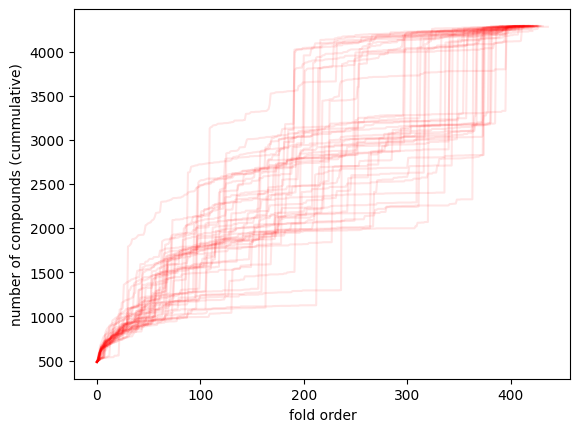

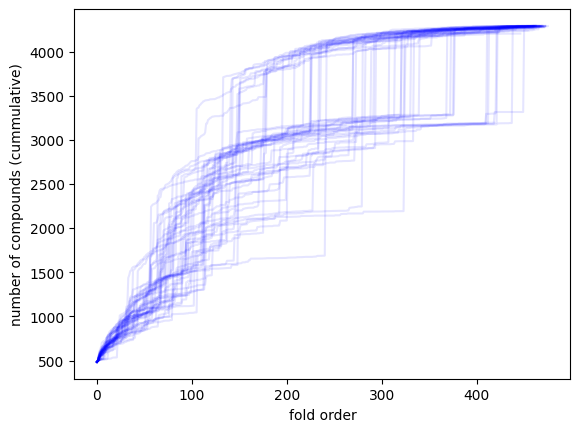

In [42]:
for run in fo2cmpdNum_shuffle_list:
    plt.plot(run.keys(), run.values(), color='red', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cmpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

for run in fo2cmpdNum_shuffle2_list:
    plt.plot(run.keys(), run.values(), color='blue', alpha = 0.1,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')
# plt.savefig('fold_order_vs_cumm_cmpds.png', dpi=300, bbox_inches = 'tight')
plt.show()

# find optimal run with the fastest growth

In [48]:
fo2cmpdNum_list[0]

{0: 80,
 1: 100,
 2: 106,
 3: 114,
 4: 123,
 5: 123,
 6: 128,
 7: 131,
 8: 132,
 9: 132,
 10: 132,
 11: 201,
 12: 260,
 13: 271,
 14: 275,
 15: 283,
 16: 286,
 17: 294,
 18: 300,
 19: 304,
 20: 304,
 21: 319,
 22: 352,
 23: 360,
 24: 361,
 25: 362,
 26: 366,
 27: 372,
 28: 372,
 29: 372,
 30: 377,
 31: 380,
 32: 380,
 33: 380,
 34: 386,
 35: 386,
 36: 398,
 37: 398,
 38: 401,
 39: 401,
 40: 401,
 41: 401,
 42: 402,
 43: 404,
 44: 405,
 45: 405,
 46: 415,
 47: 415,
 48: 415,
 49: 417,
 50: 417,
 51: 418,
 52: 418,
 53: 424,
 54: 424,
 55: 425,
 56: 425,
 57: 425,
 58: 425,
 59: 425,
 60: 427,
 61: 428,
 62: 428,
 63: 428,
 64: 428,
 65: 428,
 66: 430,
 67: 430,
 68: 430,
 69: 430,
 70: 430,
 71: 430,
 72: 430,
 73: 432,
 74: 432,
 75: 437,
 76: 438,
 77: 438,
 78: 438,
 79: 439,
 80: 439,
 81: 440,
 82: 448,
 83: 449,
 84: 449,
 85: 449,
 86: 449,
 87: 451,
 88: 453,
 89: 455,
 90: 455,
 91: 455,
 92: 455,
 93: 455,
 94: 455,
 95: 455,
 96: 457,
 97: 457,
 98: 457,
 99: 457,
 100: 457,


In [49]:
max_area = [0, 0]
index = 0
for run in fo2cmpdNum_list:
    area = sum(run.values())
    if area > max_area[1]:
        max_area = [index, area]
    index += 1
max_area

[492, 800649]

In [50]:
df_optimal.columns[492]

'42287'

In [51]:
maxDict = fo2cmpdNum_list[492]
sum(maxDict.values())

800649

In [52]:
maxDict

{0: 80,
 1: 100,
 2: 106,
 3: 114,
 4: 123,
 5: 123,
 6: 128,
 7: 131,
 8: 131,
 9: 132,
 10: 199,
 11: 258,
 12: 269,
 13: 271,
 14: 275,
 15: 283,
 16: 286,
 17: 294,
 18: 300,
 19: 304,
 20: 304,
 21: 319,
 22: 352,
 23: 360,
 24: 361,
 25: 362,
 26: 366,
 27: 372,
 28: 372,
 29: 372,
 30: 378,
 31: 383,
 32: 386,
 33: 386,
 34: 386,
 35: 386,
 36: 386,
 37: 398,
 38: 398,
 39: 398,
 40: 401,
 41: 401,
 42: 402,
 43: 412,
 44: 414,
 45: 414,
 46: 415,
 47: 417,
 48: 417,
 49: 417,
 50: 417,
 51: 417,
 52: 417,
 53: 419,
 54: 419,
 55: 425,
 56: 426,
 57: 427,
 58: 427,
 59: 427,
 60: 427,
 61: 428,
 62: 428,
 63: 428,
 64: 428,
 65: 428,
 66: 430,
 67: 430,
 68: 430,
 69: 430,
 70: 430,
 71: 430,
 72: 431,
 73: 431,
 74: 432,
 75: 432,
 76: 433,
 77: 433,
 78: 433,
 79: 435,
 80: 435,
 81: 437,
 82: 442,
 83: 442,
 84: 442,
 85: 450,
 86: 451,
 87: 451,
 88: 453,
 89: 453,
 90: 453,
 91: 453,
 92: 455,
 93: 455,
 94: 455,
 95: 455,
 96: 457,
 97: 457,
 98: 457,
 99: 457,
 100: 458,


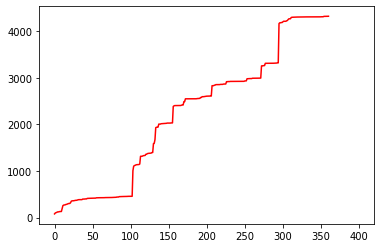

In [53]:
plt.plot(maxDict.keys(), maxDict.values(), color='red', alpha = 1,zorder=2)
plt.xlim([-20, 420])
# plt.savefig('fold_order_vs_cumm_cmpds_bestRun.png', dpi=300, bbox_inches = 'tight', transparent=True)
plt.show()

# find optimal run with the slowest growth

In [54]:
min_area = [0, 100000000]
index = 0
for run in fo2cmpdNum_list:
    area = sum(run.values())
    if area < min_area[1]:
        min_area = [index, area]
    index += 1
min_area

[658, 732400]

In [55]:
df_optimal.columns[658]

'40132'

# draw random trajectory

In [43]:
result = pd.read_pickle('/Users/longolab/Downloads/2024-06-28_23-31-19_random_fold_ordering_42687.pkl.gz')

In [48]:
fo2cmpds = {}
for c, order in result.cpds_folditer.items():
    if order not in fo2cmpds.keys():
        fo2cmpds[order] = [c]
    else:
        fo2cmpds[order].append(c)

fo2cmpdNum = {}
cumm = 0
for fo, cpds in fo2cmpds.items(): 
    fo2cmpdNum[fo] = cumm + len(cpds)
    cumm += len(cpds)

Text(0, 0.5, 'number of compounds (cummulative)')

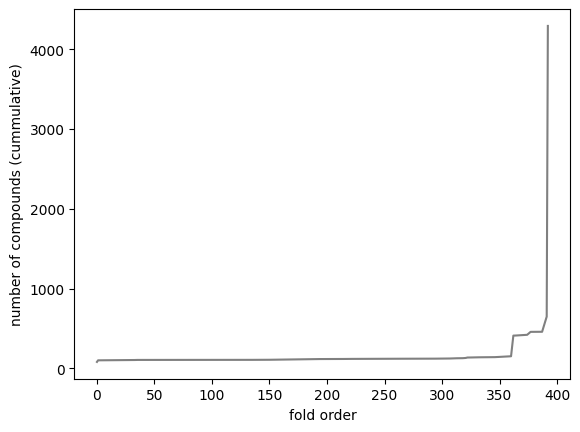

In [53]:
fo2cmpdNum
plt.plot(fo2cmpdNum.keys(), fo2cmpdNum.values(), color='gray' ,zorder=2)
plt.xlabel('fold order')
plt.ylabel('number of compounds (cummulative)')

In [ ]:
data = {k: len(vs) for k, vs in fo2cmpds_random_list[0].items()}
data_full = {}
for i in range(0, 398):
    if i not in data.keys():
        data_full[i] = 0
    else:
        data_full[i] = data[i]
data_full

In [ ]:
plt.figure(figsize=(10, 3))
plt.plot(data_full.values(), color='gray')
plt.xlim([0, len(fo2cmpdNum_random_list[0])])
plt.ylim([0, 3000])
plt.xlabel('Fold order', fontsize=16)

plt.savefig('one_random_run.svg', dpi=300, bbox_inches='tight')
plt.show()